In [900]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix, roc_curve,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#Data Wrangling

##Gathering Data

In [901]:
df = pd.read_csv('survey.csv')
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


##Asessing Data

In [902]:
df.shape

(1259, 27)

In [903]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

###Identifikasi Missing Value dan Duplikasi

In [904]:
print("Jumlah duplikasi: ", df.duplicated().sum())
df.isna().sum()


Jumlah duplikasi:  0


,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


###Identifikasi Masalah Inkonsistensi

In [905]:
print(f'Jumlah nilai unik Gender: {df["Gender"].nunique()}')
print('\nTop 30 nilai unik Gender:')
print(df['Gender'].value_counts().head(30).to_string())

Jumlah nilai unik Gender: 49

Top 30 nilai unik Gender:
Gender
Male                     615
male                     206
Female                   121
M                        116
female                    62
F                         38
m                         34
f                         15
Make                       4
Male                       3
Woman                      3
Cis Male                   2
Man                        2
Female                     2
Female (trans)             2
Male-ish                   1
Trans-female               1
Male (CIS)                 1
Mal                        1
Cis Female                 1
something kinda male?      1
maile                      1
woman                      1
Femake                     1
queer/she/they             1
Enby                       1
fluid                      1
Genderqueer                1
Androgyne                  1
Agender                    1


###Identifikasi Outlier

In [906]:
print('Distribusi Statistik Age (sebelum cleaning):')
print(df['Age'].describe())

print(f'Outlier Age (di luar umur 15-75 tahun): {len(df)-len(df)} baris')
print('Nilai outlier:')
print(df[~((df['Age']>=15)&(df['Age']<=75))]['Age'].values)

Distribusi Statistik Age (sebelum cleaning):
count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64
Outlier Age (di luar umur 15-75 tahun): 0 baris
Nilai outlier:
[        -29         329 99999999999       -1726           5           8
          11          -1]


##Cleaning Data

In [907]:
#Mengatasi masalah duplikasi
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

###Mengatasi Masalah Missing Value

In [908]:
df.work_interfere.value_counts()

,count
work_interfere,
Sometimes,465
Never,213
Rarely,173
Often,144


In [909]:
df.self_employed.value_counts()

,count
self_employed,
No,1095
Yes,146


In [910]:
# kolom work-interfere dan self-employed yang kosong diganti dengan nilai modus
df['work_interfere'].fillna('No', inplace=True)
df['self_employed'].fillna('Sometimes', inplace=True)


/tmp/ipykernel_7299/2839656942.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['work_interfere'].fillna('No', inplace=True)
/tmp/ipykernel_7299/2839656942.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [911]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1259 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             1259 non-null   object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

###Mengatasi Masalah Inkonsistensi

In [912]:
#Memperbaiki inkonsistensi gender
fem_list = [
    'F', 'female', 'Woman', 'woman', 'Female', 'Femake',
    'femail', 'f', 'cis-female/femme', 'Cis Female'
]

male_list = [
    'male','man','maile','cis male'
]

df['Gender_clean'] = df['Gender'].str.strip().str.lower()

# ubah list ke lowercase
fem_set = set([x.lower().strip() for x in fem_list])
male_set = set([x.lower().strip() for x in male_list])

def map_gender(x):
    if x in fem_set:
        return 'Female'
    elif x in male_set:
        return 'Male'
    else:
        return 'Others'

df['Gender'] = df['Gender_clean'].apply(map_gender)


df.drop(columns='Gender_clean', inplace=True)

In [913]:
df.Gender.value_counts()

,count
Gender,
Male,830
Female,246
Others,183


###Mengatasi Masalah Outlier

Age filter: 1259 → 1251 baris (removed 8)


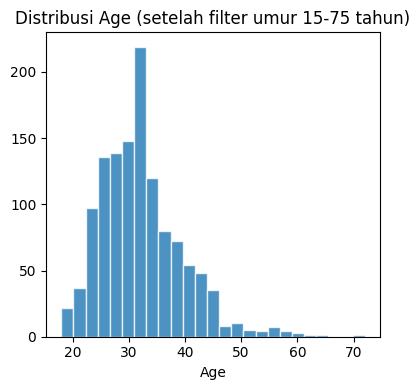

In [914]:
# Filter Kolom Age
before = len(df)
df = df[(df['Age']>=15)&(df['Age']<=75)]
print(f'Age filter: {before} → {len(df)} baris (removed {before-len(df)})')

fig, axes = plt.subplots(figsize=(4,4))

df = df[(df['Age']>=15)&(df['Age']<=75)]
axes.hist(df['Age'], bins=25, edgecolor='white', alpha=0.8)
axes.set_title('Distribusi Age (setelah filter umur 15-75 tahun)')
axes.set_xlabel('Age')
plt.tight_layout(); plt.show()



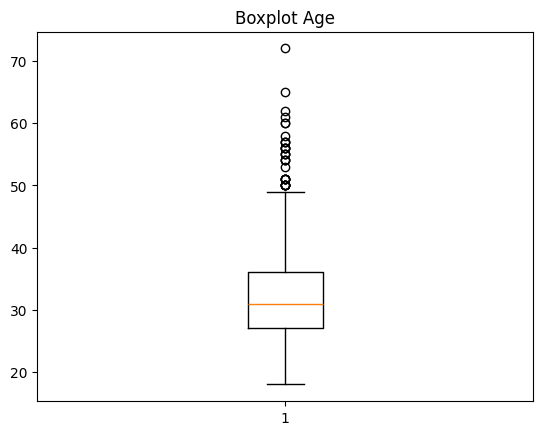

In [915]:
#Validasi hasil
plt.boxplot(df['Age'])
plt.title('Boxplot Age')
plt.show()

In [916]:
#Menghapus kolom Timestamp, Country, state, dan comments
df.drop(['Timestamp', 'Country','state', 'comments'], axis=1, inplace=True)
df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,Sometimes,No,Yes,Often,6-25,No,Yes,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Others,Sometimes,No,No,Rarely,More than 1000,No,No,Don't know,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Sometimes,No,No,Rarely,6-25,No,Yes,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,Sometimes,Yes,Yes,Often,26-100,No,Yes,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,Sometimes,No,No,Never,100-500,Yes,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


In [917]:
#eksport dataset df yang telah bersih
df_clean = df.copy()
print(f'  Shape: {df_clean.shape}')
df_clean.to_csv('survey_clean.csv', index=False)

  Shape: (1251, 23)


#Exploratory Data Analysis

##Analisis Univariat

###Distribusi Variabel Numerik

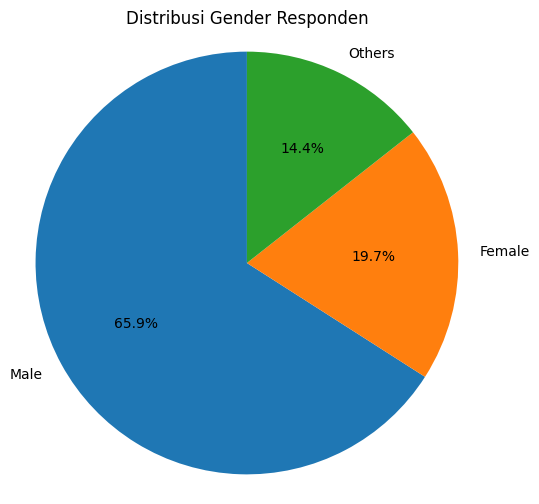

In [918]:
gender_counts = df_clean['Gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Gender Responden')
plt.axis('equal')
plt.show()

###Distribusi Variabel Kategorik

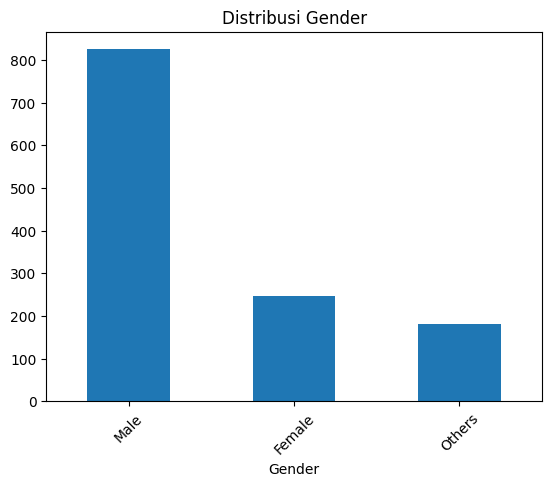

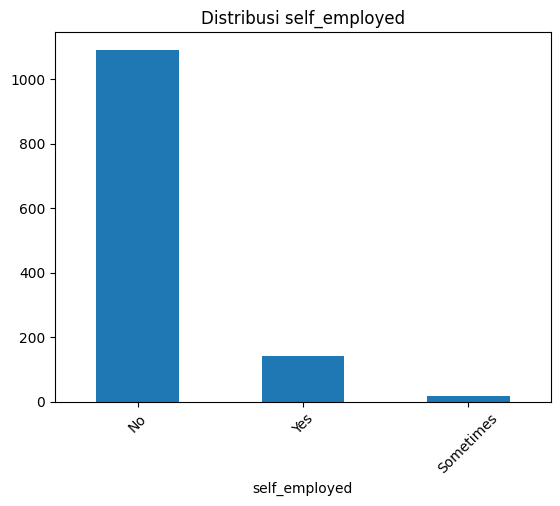

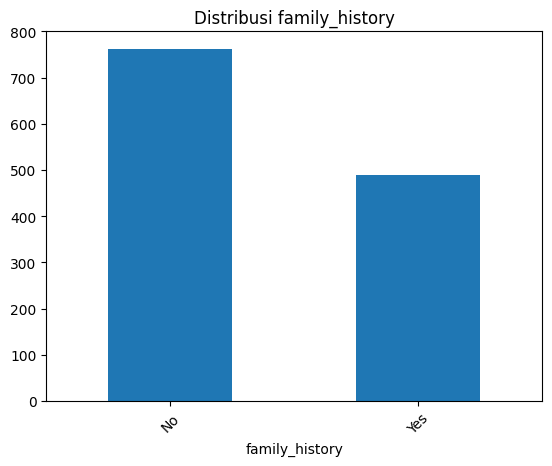

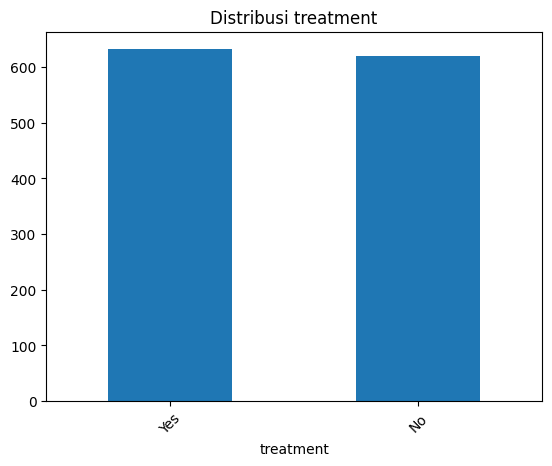

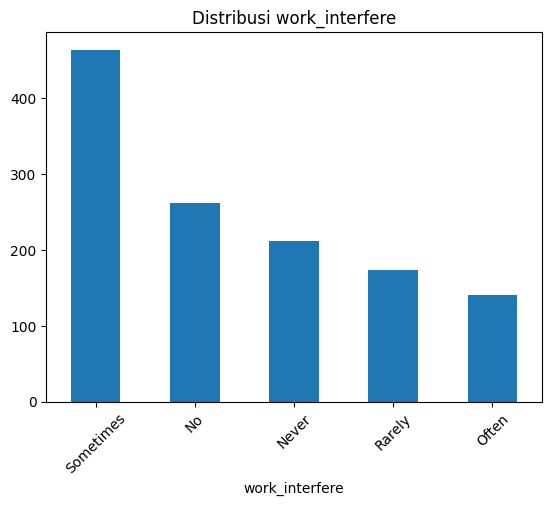

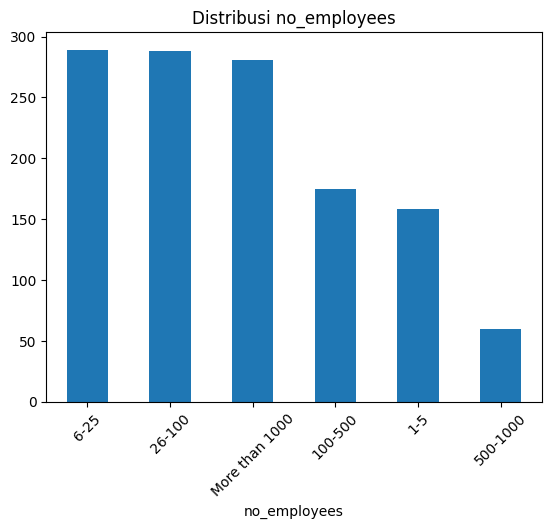

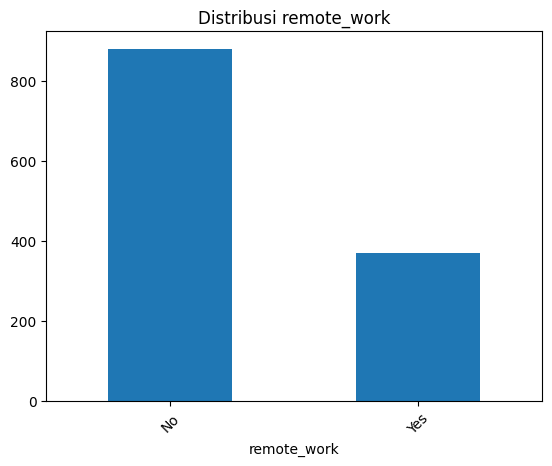

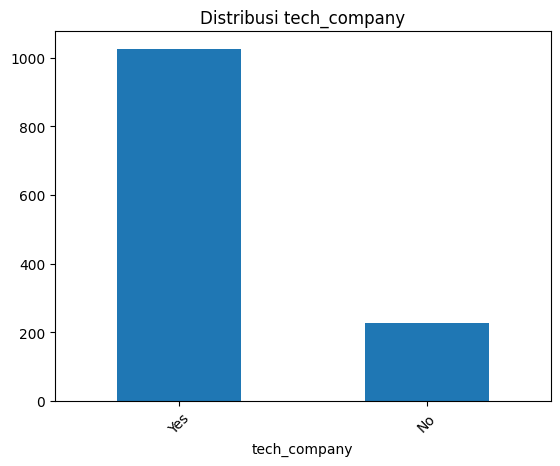

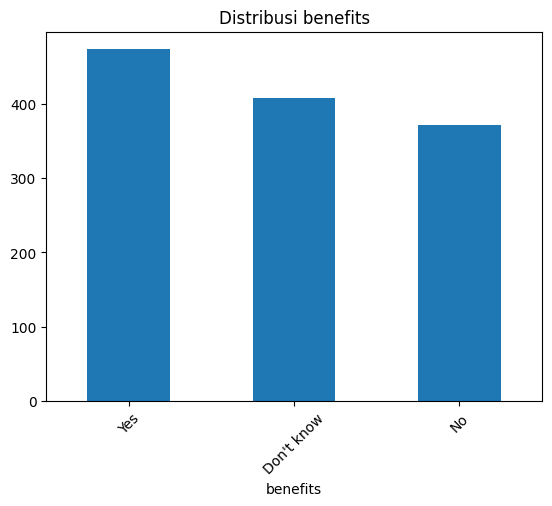

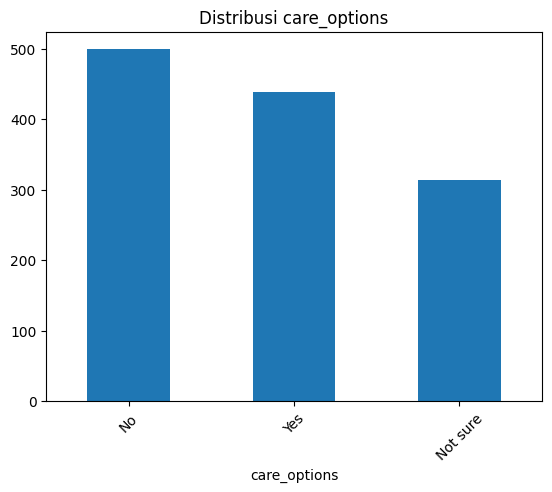

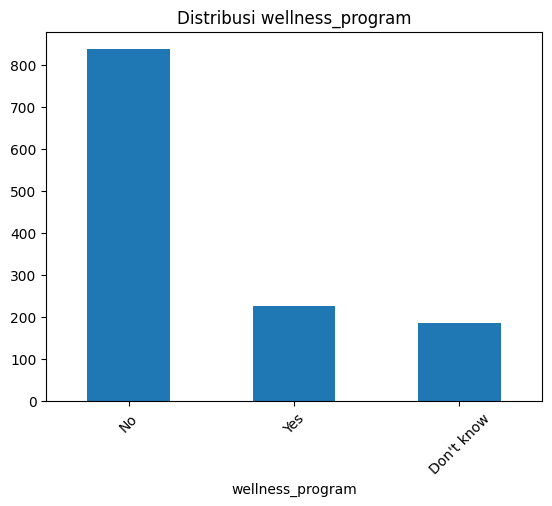

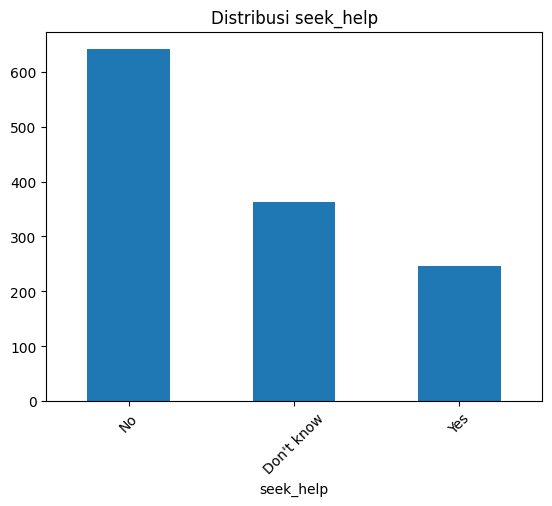

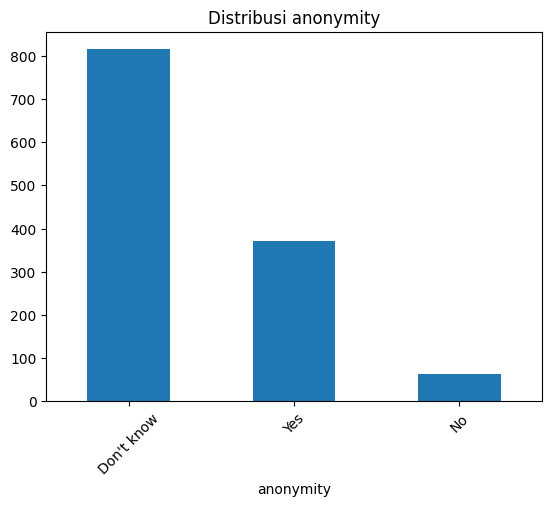

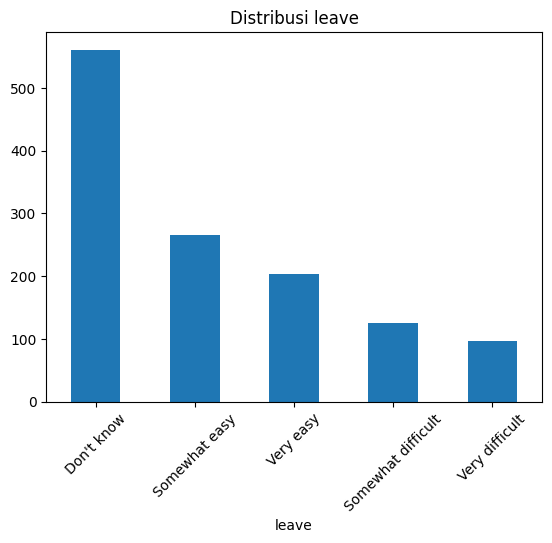

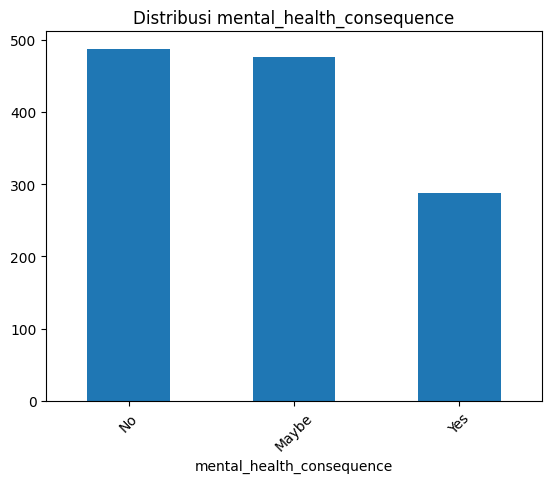

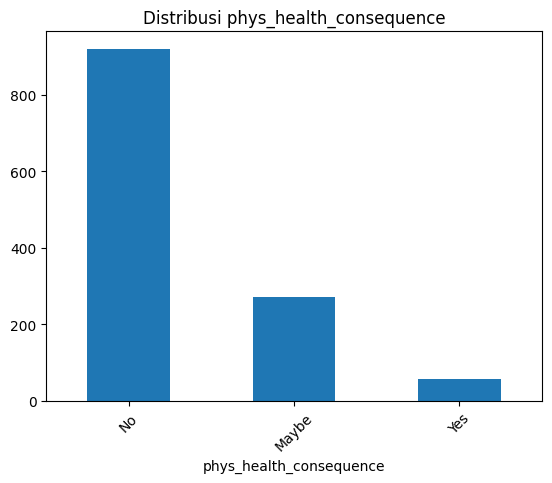

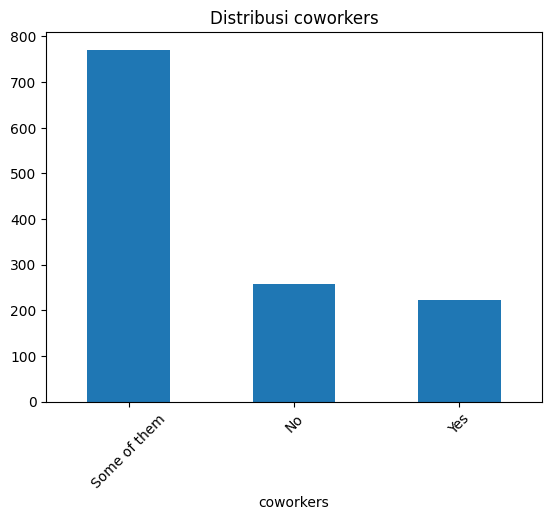

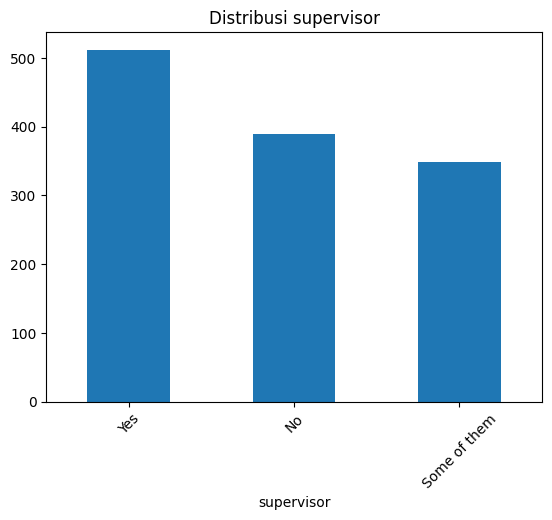

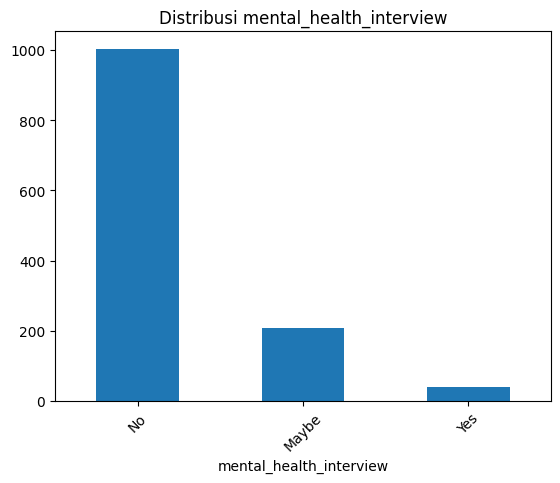

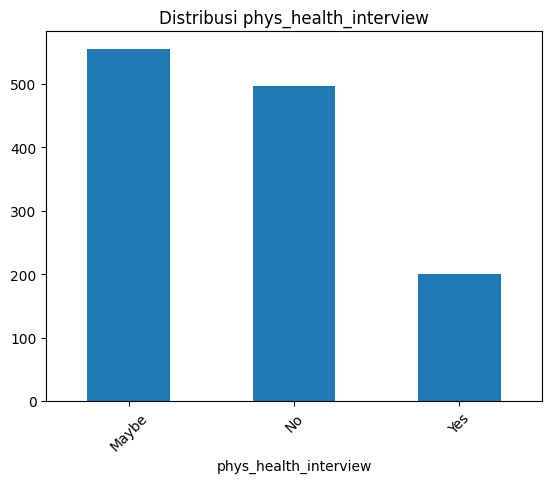

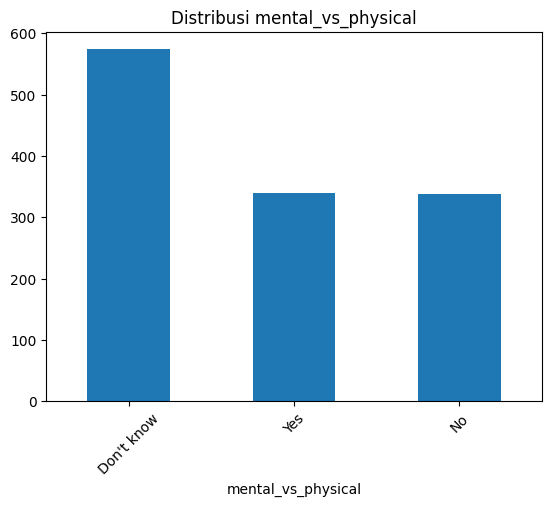

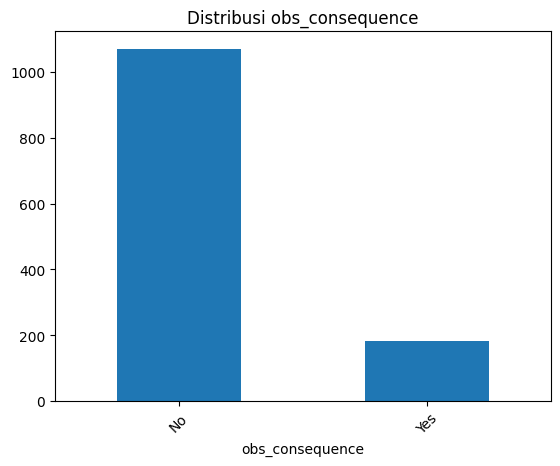

In [919]:
cat_cols = df_clean.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    df_clean[col].value_counts().plot(kind='bar')
    plt.title(f'Distribusi {col}')
    plt.xticks(rotation=45)
    plt.show()

##Analisis Bivariat

###Distribusi Gender dan Treatment

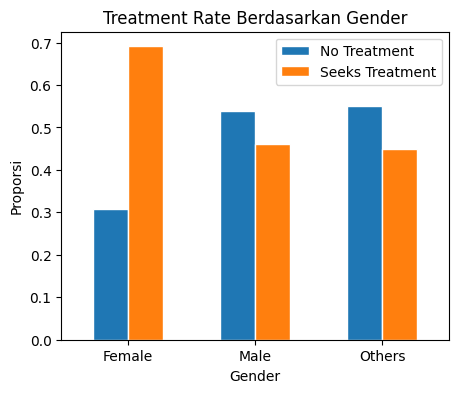

In [920]:
# Jumlah treatment berdasarkan gender
gender_summary = (
    df_clean
    .groupby('Gender')['treatment']
    .value_counts(normalize=True)
    .unstack()
)
fig, ax = plt.subplots(figsize=(5, 4))

# Visualisasi bar chart
gender_summary.plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='white',
    width=0.55,
    rot=0
)

ax.set_title('Treatment Rate Berdasarkan Gender', fontsize=12)
ax.set_xlabel('Gender')
ax.set_ylabel('Proporsi')
ax.legend(['No Treatment', 'Seeks Treatment'])

###Distribusi Family History dan Treatment

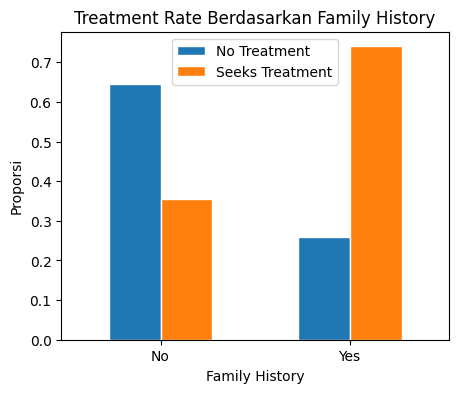

In [921]:
fh_summary = (
    df_clean
    .groupby('family_history')['treatment']
    .value_counts(normalize=True)
    .unstack()
)
fig, ax = plt.subplots(figsize=(5, 4))

# Visualisasi bar chart
fh_summary.plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='white',
    width=0.55,
    rot=0
)

ax.set_title('Treatment Rate Berdasarkan Family History', fontsize=12)
ax.set_xlabel('Family History')
ax.set_ylabel('Proporsi')
ax.legend(['No Treatment', 'Seeks Treatment'])

###Distribusi Wellness Interference dan Treatment

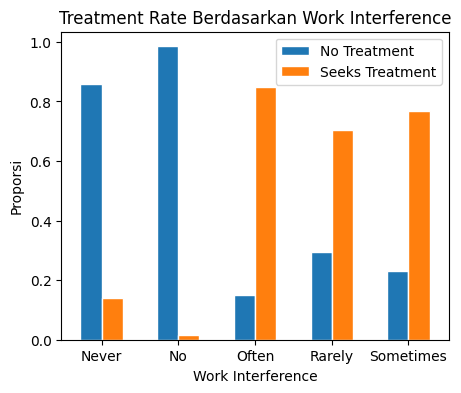

In [922]:
wi_summary = (
    df_clean
    .groupby('work_interfere')['treatment']
    .value_counts(normalize=True)
    .unstack()
)
fig, ax = plt.subplots(figsize=(5, 4))

# Visualisasi bar chart
wi_summary.plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='white',
    width=0.55,
    rot=0
)

ax.set_title('Treatment Rate Berdasarkan Work Interference', fontsize=12)
ax.set_xlabel('Work Interference')
ax.set_ylabel('Proporsi')
ax.legend(['No Treatment', 'Seeks Treatment'])

###Benefits dan Treatment

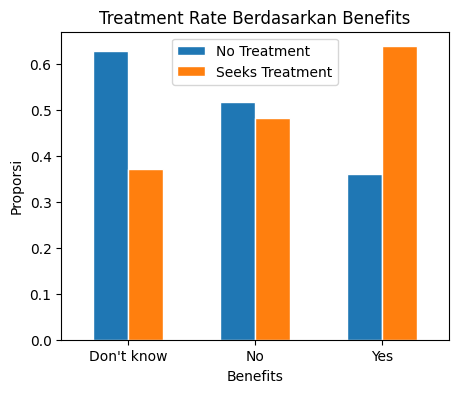

In [923]:
benefits_summary = (
    df_clean
    .groupby('benefits')['treatment']
    .value_counts(normalize=True)
    .unstack()
)
fig, ax = plt.subplots(figsize=(5, 4))

# Visualisasi bar chart
benefits_summary.plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='white',
    width=0.55,
    rot=0
)

ax.set_title('Treatment Rate Berdasarkan Benefits', fontsize=12)
ax.set_xlabel('Benefits')
ax.set_ylabel('Proporsi')
ax.legend(['No Treatment', 'Seeks Treatment'])

###Care Options dan Treatment

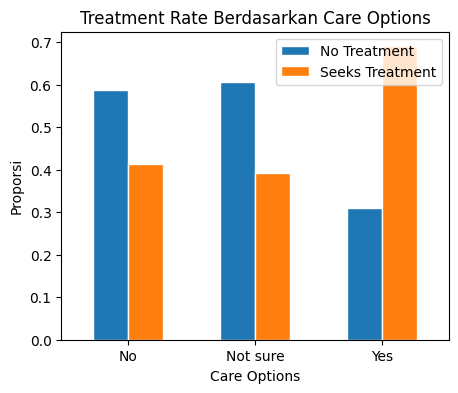

In [924]:
co_summary = (
    df_clean
    .groupby('care_options')['treatment']
    .value_counts(normalize=True)
    .unstack()
)
fig, ax = plt.subplots(figsize=(5, 4))

# Visualisasi bar chart
co_summary.plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='white',
    width=0.55,
    rot=0
)

ax.set_title('Treatment Rate Berdasarkan Care Options', fontsize=12)
ax.set_xlabel('Care Options')
ax.set_ylabel('Proporsi')
ax.legend(['No Treatment', 'Seeks Treatment'])

###Distribusi Wellness Program dan Treatment

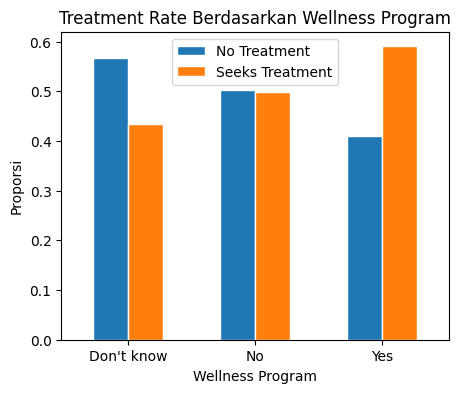

In [925]:
wp_summary = (
    df_clean
    .groupby('wellness_program')['treatment']
    .value_counts(normalize=True)
    .unstack()
)
fig, ax = plt.subplots(figsize=(5, 4))

# Visualisasi bar chart
wp_summary.plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e'],
    edgecolor='white',
    width=0.55,
    rot=0
)

ax.set_title('Treatment Rate Berdasarkan Wellness Program', fontsize=12)
ax.set_xlabel('Wellness Program')
ax.set_ylabel('Proporsi')
ax.legend(['No Treatment', 'Seeks Treatment'])

##Korelasi Data

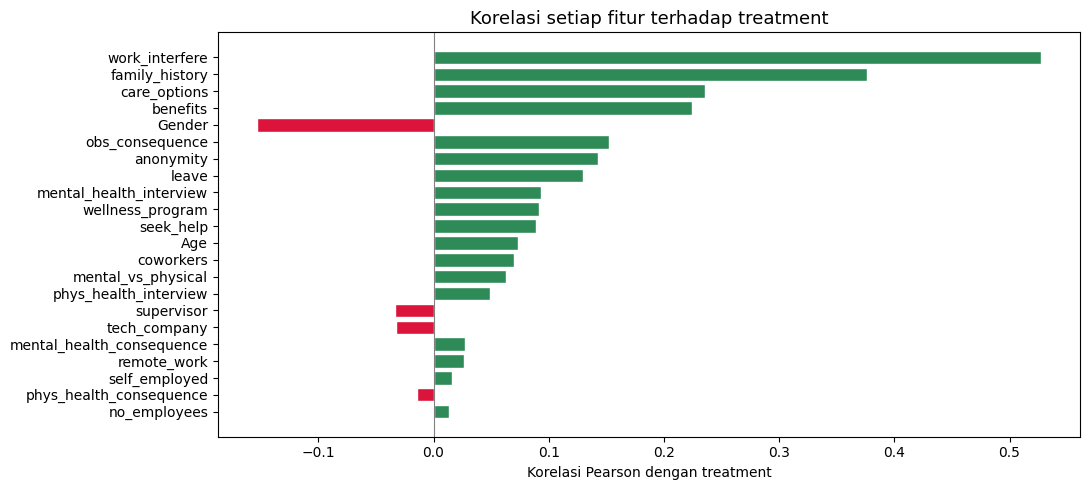

5 fitur paling kuat
work_interfere    0.527173
family_history    0.376674
care_options      0.235429
benefits          0.224731
Gender            0.153117


In [926]:
df_corr = df_clean.copy()
df_corr['treatment_bin'] = (df_corr['treatment']=='Yes').astype(int)
df_corr.drop(columns=['treatment'], inplace=True)

ordinal_maps = {
    'leave':{'Very easy':0,'Somewhat easy':1,'Unknown':2,'Somewhat difficult':3,'Very difficult':4},
    'work_interfere':{'Never':0,'Rarely':1,'Sometimes':2,'Often':3,},
    'no_employees':{'1-5':0,'6-25':1,'26-100':2,'100-500':3,'500-1000':4,'More than 1000':5},
}
for col,mapping in ordinal_maps.items():
    df_corr[col] = df_corr[col].map(mapping).fillna(1)
le = LabelEncoder()
for c in list(df_corr.select_dtypes(include='object').columns):
    df_corr[c] = le.fit_transform(df_corr[c].astype(str))

corr_target = df_corr.corr()['treatment_bin'].drop('treatment_bin').sort_values(key=abs,ascending=False)

fig, ax = plt.subplots(figsize=(11,5))
colors = ['#2E8B57' if v > 0 else '#DC143C' for v in corr_target]
bars = ax.barh(corr_target.index[::-1], corr_target.values[::-1],
    color=colors[::-1], edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Korelasi Pearson dengan treatment')
ax.set_title('Korelasi setiap fitur terhadap treatment', fontsize=13)
plt.tight_layout(); plt.show()

print('5 fitur paling kuat')
print(corr_target.abs().sort_values(ascending=False).head(5).to_string())

##Encoding

In [927]:
#Melakukan encoding pada target treatment
df_clean['treatment'] = (df_clean['treatment']=='Yes').astype(int)

#Ordinal Encoding
ordinal_maps = {
    'leave':{'Very easy':0,'Somewhat easy':1,'Unknown':2,'Somewhat difficult':3,'Very difficult':4},
    'work_interfere':{'Never':0,'Rarely':1,'Sometimes':2,'Often':3,},
    'no_employees':{'1-5':0,'6-25':1,'26-100':2,'100-500':3,'500-1000':4,'More than 1000':5},
}

X = df_clean.drop(columns=['treatment'])
y = df_clean['treatment']

for col,mapping in ordinal_maps.items():
    X[col] = X[col].map(mapping).fillna(1)

label_encoder = LabelEncoder()
for c in list(X.select_dtypes(include='object').columns):
    X[c] = label_encoder.fit_transform(X[c].astype(str))

X.describe()

,Age,Gender,self_employed,family_history,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
count,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,...,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000
mean,32.076739,0.947242,0.241407,0.390887,1.425260,2.426059,0.296563,0.819345,1.052758,0.952038,...,0.645883,1.270184,0.849720,0.828137,0.971223,1.097522,0.867306,0.716227,0.812150,0.144684
std,7.288272,0.581390,0.640684,0.488144,0.898782,1.705968,0.456925,0.384886,0.837385,0.864926,...,0.907800,1.089836,0.767201,0.485015,0.619008,0.843849,0.425180,0.723470,0.833717,0.351923
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,31.000000,1.000000,0.000000,0.000000,1.000000,2.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,36.000000,1.000000,0.000000,1.000000,2.000000,4.000000,1.000000,1.000000,2.000000,2.000000,...,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,0.000000
max,72.000000,2.000000,2.000000,1.000000,3.000000,5.000000,1.000000,1.000000,2.000000,2.000000,...,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000


#Train/Test Split Dataset

In [928]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print(f'Jumlah data train: {len(X_train)} samples ({len(X_train)/len(X):.0%})')
print(f'Jumlah data test: {len(X_test)} samples ({len(X_test)/len(X):.0%})')

Jumlah data train: 1000 samples (80%)
Jumlah data test: 251 samples (20%)


#Model Baseline

HASIL BASELINE MODEL - STRATIFIED K-FOLD
Logistic Regression       F1-Score: 0.7914 (+/- 0.0097)
Random Forest             F1-Score: 0.7961 (+/- 0.0122)
Gradient Boosting         F1-Score: 0.7821 (+/- 0.0270)


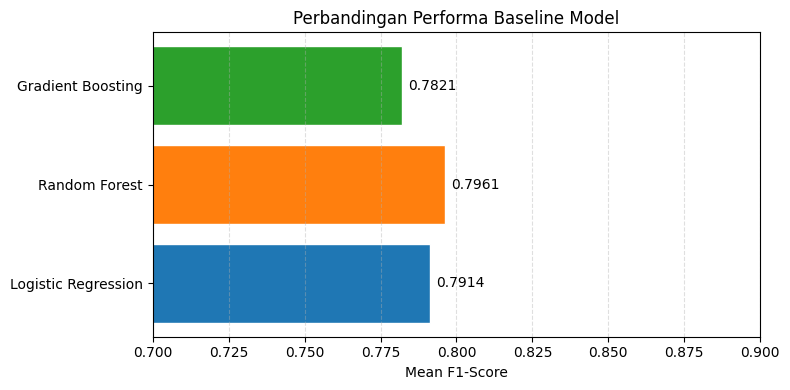

In [929]:
# =========================================================
# DAFTAR MODEL BASELINE
# =========================================================
candidate_models = {
    'Logistic Regression': (
        LogisticRegression(
            max_iter=300,
            C=1,
            random_state=42
        ),
        X_train_scaled
    ),

    'Random Forest': (
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        X_train
    ),

    'Gradient Boosting': (
        GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ),
        X_train
    )
}

# =========================================================
# CROSS VALIDATION BASELINE
# =========================================================
print('=' * 55)
print('HASIL BASELINE MODEL - STRATIFIED K-FOLD')
print('=' * 55)

model_scores = {}

for model_name, (estimator, feature_data) in candidate_models.items():

    cv_result = cross_val_score(
        estimator,
        feature_data,
        y_train,
        cv=skf,
        scoring='f1'
    )

    mean_score = cv_result.mean()
    std_score = cv_result.std()

    model_scores[model_name] = mean_score

    print(
        f'{model_name:<25} '
        f'F1-Score: {mean_score:.4f} '
        f'(+/- {std_score:.4f})'
    )

# =========================================================
# VISUALISASI PERFORMA MODEL
# =========================================================
fig, axis = plt.subplots(figsize=(8,4))

# Data visualisasi
model_labels = list(model_scores.keys())
score_values = list(model_scores.values())

plot_bar = axis.barh(
    model_labels,
    score_values,
    color=['#1f77b4', '#ff7f0e', '#2ca02c'],
    edgecolor='white'
)

# Menambahkan label skor
for rectangle, score in zip(plot_bar, score_values):

    axis.text(
        score + 0.002,
        rectangle.get_y() + rectangle.get_height()/2,
        f'{score:.4f}',
        va='center'
    )

# visualisasi
axis.set_xlim(0.70, 0.90)

axis.set_xlabel('Mean F1-Score')
axis.set_title('Perbandingan Performa Baseline Model')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#Hyperparameter Tuning

In [930]:
print('Random Forest Hyperparameter Tuning')
highest_f1 = 0
optimal_parameter = {}
tree_list = [100, 200, 300]
depth_list = [None, 10, 15]
feature_list = ['sqrt', 'log2']
# Iterasi seluruh kombinasi parameter
for total_tree in tree_list:

    for max_depth_value in depth_list:

        for max_feature_value in feature_list:

            # Membuat model
            rf_candidate = RandomForestClassifier(
                n_estimators=total_tree,
                max_depth=max_depth_value,
                max_features=max_feature_value,
                random_state=42
            )

            # Cross Validation
            cv_f1 = cross_val_score(
                rf_candidate,
                X_train,
                y_train,
                cv=skf,
                scoring='f1'
            ).mean()

            # Menyimpan parameter terbaik
            if cv_f1 > highest_f1:

                highest_f1 = cv_f1

                optimal_parameter = {
                    'n_estimators': total_tree,
                    'max_depth': max_depth_value,
                    'max_features': max_feature_value
                }
best_random_forest = RandomForestClassifier(
    **optimal_parameter,
    random_state=42
)

# Training model terbaik
best_random_forest.fit(X_train, y_train)

# Prediksi data test
rf_test_prediction = best_random_forest.predict(X_test)

# Probabilitas prediksi
rf_test_probability = best_random_forest.predict_proba(X_test)[:, 1]

# =========================================================
# EVALUASI MODEL
# =========================================================
rf_f1_test = f1_score(y_test, rf_test_prediction)

rf_auc_score = roc_auc_score(
    y_test,
    rf_test_probability
)

# =========================================================
# HASIL EVALUASI
# =========================================================
print(f'Best Cross Validation F1 : {highest_f1:.4f}')
print(f'Test F1-Score            : {rf_f1_test:.4f}')
print(f'ROC-AUC Score            : {rf_auc_score:.4f}')

print('\nBest Hyperparameters:')
print(optimal_parameter)

Random Forest Hyperparameter Tuning
Best Cross Validation F1 : 0.8125
Test F1-Score            : 0.7798
ROC-AUC Score            : 0.8232

Best Hyperparameters:
{'n_estimators': 300, 'max_depth': None, 'max_features': 'sqrt'}


In [931]:
print('GRADIENT BOOSTING HYPERPARAMETER TUNING')

optimal_gb_f1 = 0
optimal_gb_setting = {}

# Daftar kandidat hyperparameter
boosting_estimators = [100, 200]
learning_rate_values = [0.05, 0.1, 0.2]
tree_depth_values = [3, 4, 5]

# =========================================================
# ITERASI KOMBINASI PARAMETER
# =========================================================
for estimator_value in boosting_estimators:

    for lr_value in learning_rate_values:

        for depth_value in tree_depth_values:

            # Membentuk model kandidat
            gb_candidate_model = GradientBoostingClassifier(
                n_estimators=estimator_value,
                learning_rate=lr_value,
                max_depth=depth_value,
                random_state=42
            )

            # Evaluasi cross validation
            validation_score = cross_val_score(
                gb_candidate_model,
                X_train,
                y_train,
                cv=skf,
                scoring='f1'
            ).mean()

            # Menyimpan performa terbaik
            if validation_score > optimal_gb_f1:

                optimal_gb_f1 = validation_score

                optimal_gb_setting = {
                    'n_estimators': estimator_value,
                    'learning_rate': lr_value,
                    'max_depth': depth_value
                }

# =========================================================
# MEMBANGUN MODEL TERBAIK
# =========================================================
final_gradient_boosting = GradientBoostingClassifier(
    **optimal_gb_setting,
    random_state=42
)

# Training model
final_gradient_boosting.fit(X_train, y_train)

# =========================================================
# PREDIKSI DATA TEST
# =========================================================
gb_prediction = final_gradient_boosting.predict(X_test)

# Prediksi probabilitas
gb_probability = final_gradient_boosting.predict_proba(X_test)[:, 1]

# =========================================================
# EVALUASI MODEL
# =========================================================
gb_test_f1 = f1_score(
    y_test,
    gb_prediction
)

gb_roc_auc = roc_auc_score(
    y_test,
    gb_probability
)

print(f'Best CV F1-Score   : {optimal_gb_f1:.4f}')
print(f'Test F1-Score      : {gb_test_f1:.4f}')
print(f'ROC-AUC Score      : {gb_roc_auc:.4f}')

print('\nOptimal Hyperparameter:')
print(optimal_gb_setting)

GRADIENT BOOSTING HYPERPARAMETER TUNING
Best CV F1-Score   : 0.7978
Test F1-Score      : 0.7726
ROC-AUC Score      : 0.8140

Optimal Hyperparameter:
{'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5}


In [932]:
print('LOGISTIC REGRESSION HYPERPARAMETER TUNING')


# Variabel penyimpan performa terbaik
top_f1_score = 0
selected_parameter = {}

# Kandidat parameter
regularization_values = [0.01, 0.1, 1, 10, 100]
penalty_types = ['l1', 'l2']

# =========================================================
# PENCARIAN KOMBINASI PARAMETER TERBAIK
# =========================================================
for regularization_strength in regularization_values:

    for penalty_option in penalty_types:

        # Membuat model kandidat
        logistic_candidate = LogisticRegression(
            C=regularization_strength,
            penalty=penalty_option,
            solver='liblinear',
            max_iter=500,
            random_state=42
        )

        # Evaluasi cross validation
        mean_cv_score = cross_val_score(
            logistic_candidate,
            X_train_scaled,
            y_train,
            cv=skf,
            scoring='f1'
        ).mean()

        # Menyimpan parameter terbaik
        if mean_cv_score > top_f1_score:

            top_f1_score = mean_cv_score

            selected_parameter = {
                'C': regularization_strength,
                'penalty': penalty_option
            }

# =========================================================
# MEMBANGUN MODEL TERBAIK
# =========================================================
optimized_logistic_model = LogisticRegression(
    **selected_parameter,
    solver='liblinear',
    max_iter=500,
    random_state=42
)

# Training model
optimized_logistic_model.fit(
    X_train_scaled,
    y_train
)

# =========================================================
# PREDIKSI DATA TEST
# =========================================================
logistic_prediction = optimized_logistic_model.predict(
    X_test_scaled
)

# Prediksi probabilitas
logistic_probability = optimized_logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

# =========================================================
# EVALUASI MODEL
# =========================================================
final_f1_score = f1_score(
    y_test,
    logistic_prediction
)

final_auc_score = roc_auc_score(
    y_test,
    logistic_probability
)

# =========================================================
# HASIL AKHIR
# =========================================================
print(f'Best Cross Validation F1 : {top_f1_score:.4f}')
print(f'Test F1-Score            : {final_f1_score:.4f}')
print(f'ROC-AUC Score            : {final_auc_score:.4f}')

print('\nBest Hyperparameter:')
print(selected_parameter)

LOGISTIC REGRESSION HYPERPARAMETER TUNING
Best Cross Validation F1 : 0.7951
Test F1-Score            : 0.7612
ROC-AUC Score            : 0.8250

Best Hyperparameter:
{'C': 0.1, 'penalty': 'l1'}


#Evaluasi Model Terbaik

In [933]:
model_auc_result = {
    'Random Forest': rf_auc_score,
    'Gradient Boosting': gb_roc_auc,
    'Logistic Regression': final_auc_score
}

# =========================================================
# MENENTUKAN MODEL TERBAIK
# =========================================================
best_model_name = max(
    model_auc_result,
    key=model_auc_result.get
)

# =========================================================
# MENYIMPAN INFORMASI SETIAP MODEL
# =========================================================
trained_models = {

    'Random Forest': {
        'model': best_random_forest,
        'prediction': rf_test_prediction,
        'probability': rf_test_probability,
        'parameter': optimal_parameter
    },

    'Gradient Boosting': {
        'model': final_gradient_boosting,
        'prediction': gb_prediction,
        'probability': gb_probability,
        'parameter': optimal_gb_setting
    },

    'Logistic Regression': {
        'model': optimized_logistic_model,
        'prediction': logistic_prediction,
        'probability': logistic_probability,
        'parameter': selected_parameter
    }
}

# =========================================================
# MENGAMBIL MODEL TERBAIK
# =========================================================
selected_model_info = trained_models[best_model_name]

best_prediction = selected_model_info['prediction']
best_probability = selected_model_info['probability']
best_parameter = selected_model_info['parameter']

# =========================================================
# EVALUASI MODEL TERBAIK
# =========================================================
best_accuracy = accuracy_score(
    y_test,
    best_prediction
)

best_f1 = f1_score(
    y_test,
    best_prediction
)

best_auc = roc_auc_score(
    y_test,
    best_probability
)

# =========================================================
# MENAMPILKAN HASIL CHAMPION MODEL
# =========================================================
print('=' * 60)
print('PERFORMA MODEL TERBAIK')
print('=' * 60)

print(f'Model Terbaik : {best_model_name}')
print(f'Accuracy      : {best_accuracy:.4f}')
print(f'F1-Score      : {best_f1:.4f}')
print(f'ROC-AUC Score : {best_auc:.4f}')

print('\nHyperparameter Terbaik:')
print(best_parameter)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================
print('\nClassification Report:')
print(
    classification_report(
        y_test,
        best_prediction,
        target_names=[
            'No Treatment',
            'Needs Treatment'
        ]
    )
)

PERFORMA MODEL TERBAIK
Model Terbaik : Logistic Regression
Accuracy      : 0.7450
F1-Score      : 0.7612
ROC-AUC Score : 0.8250

Hyperparameter Terbaik:
{'C': 0.1, 'penalty': 'l1'}

Classification Report:
                 precision    recall  f1-score   support

   No Treatment       0.70      0.75      0.73       113
Needs Treatment       0.78      0.74      0.76       138

       accuracy                           0.75       251
      macro avg       0.74      0.75      0.74       251
   weighted avg       0.75      0.75      0.75       251



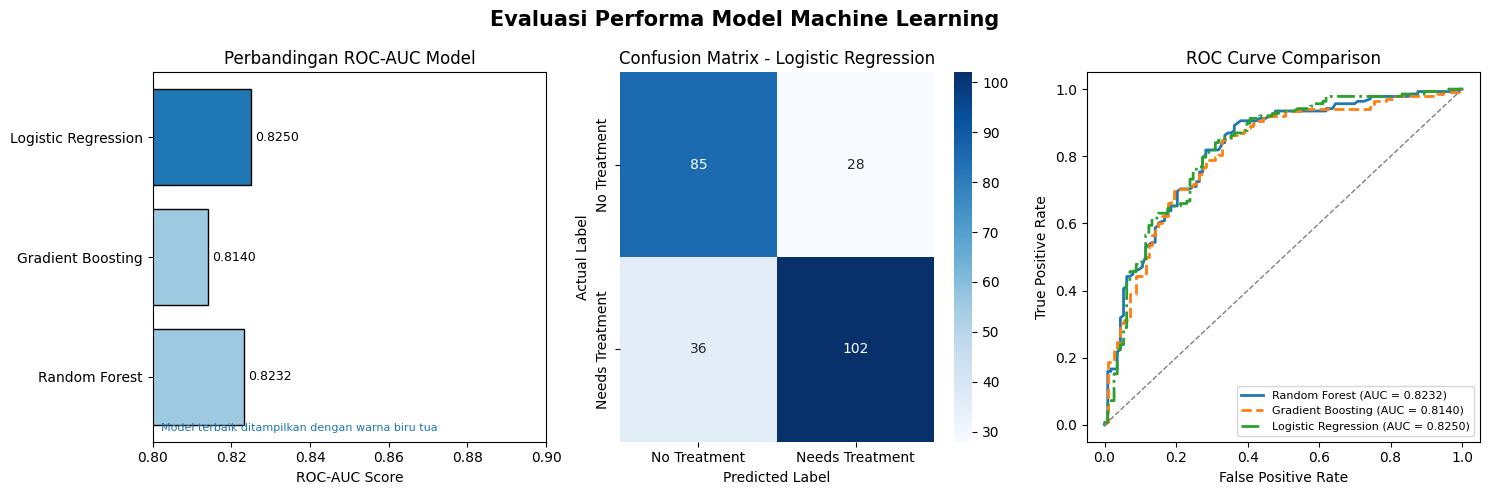

In [934]:
figure, plot_axis = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

figure.suptitle(
    'Evaluasi Performa Model Machine Learning',
    fontsize=15,
    fontweight='bold'
)
comparison_models = list(model_auc_result.keys())
comparison_scores = list(model_auc_result.values())

# Warna model terbaik
bar_colors = []

for model_label in comparison_models:

    if model_label == best_model_name:
        bar_colors.append('#1f77b4')
    else:
        bar_colors.append('#9ecae1')

# Horizontal bar chart
auc_plot = plot_axis[0].barh(
    comparison_models,
    comparison_scores,
    color=bar_colors,
    edgecolor='black'
)

# Label skor
for bar_item, score_item in zip(
    auc_plot,
    comparison_scores
):

    plot_axis[0].text(
        score_item + 0.001,
        bar_item.get_y() + bar_item.get_height()/2,
        f'{score_item:.4f}',
        va='center',
        fontsize=9
    )

plot_axis[0].set_xlim(0.80, 0.90)

plot_axis[0].set_xlabel('ROC-AUC Score')
plot_axis[0].set_title('Perbandingan ROC-AUC Model')

plot_axis[0].text(
    0.02,
    0.03,
    'Model terbaik ditampilkan dengan warna biru tua',
    transform=plot_axis[0].transAxes,
    fontsize=8,
    color='#1f77b4'
)

# =========================================================
# 2. CONFUSION MATRIX MODEL TERBAIK
# =========================================================
best_conf_matrix = confusion_matrix(
    y_test,
    best_prediction
)

sns.heatmap(
    best_conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=plot_axis[1],
    xticklabels=[
        'No Treatment',
        'Needs Treatment'
    ],
    yticklabels=[
        'No Treatment',
        'Needs Treatment'
    ]
)

plot_axis[1].set_title(
    f'Confusion Matrix - {best_model_name}'
)

plot_axis[1].set_xlabel('Predicted Label')
plot_axis[1].set_ylabel('Actual Label')

# =========================================================
# 3. ROC CURVE SELURUH MODEL
# =========================================================
roc_information = [

    (
        'Random Forest',
        rf_test_probability,
        '#1f77b4',
        '-'
    ),

    (
        'Gradient Boosting',
        gb_probability,
        '#ff7f0e',
        '--'
    ),

    (
        'Logistic Regression',
        logistic_probability,
        '#2ca02c',
        '-.'
    )
]

# Plot ROC tiap model
for label_name, probability_value, line_color, line_style in roc_information:

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probability_value
    )

    plot_axis[2].plot(
        false_positive_rate,
        true_positive_rate,
        label=f'{label_name} (AUC = {model_auc_result[label_name]:.4f})',
        color=line_color,
        linewidth=2,
        linestyle=line_style
    )

# Garis baseline random classifier
plot_axis[2].plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray',
    linewidth=1
)

plot_axis[2].set_xlabel('False Positive Rate')
plot_axis[2].set_ylabel('True Positive Rate')

plot_axis[2].set_title('ROC Curve Comparison')

plot_axis[2].legend(fontsize=8)

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()

plt.show()